In [1]:
import pandas as pd
import numpy as np


In [2]:
# Load Dataset
# -----------------------------
df = pd.read_csv("data/AmesHousing_engineered.csv")
df

,Order,PID,MS SubClass,Lot Shape,Land Slope,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,Exter Qual,...,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,HouseAge,Log_LotArea
0,0.000000,0.000000,0.000000,1.098612,2,0.500,0.637681,0.166667,0.067659,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.362319,0.074608
1,0.000341,0.000102,0.000000,1.386294,2,0.625,0.644928,0.183333,0.000000,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.355072,0.047118
2,0.000683,0.000104,0.000000,1.098612,2,0.625,0.623188,0.133333,0.065319,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.376812,0.058843
3,0.001024,0.000108,0.000000,1.386294,2,0.500,0.695652,0.300000,0.000000,1.386294,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.304348,0.045056
4,0.001366,0.001672,0.211309,1.098612,2,0.500,0.905797,0.800000,0.000000,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.094203,0.056916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,0.998634,0.825655,0.302281,1.098612,2,0.625,0.811594,0.566667,0.000000,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.811594,0.030551
2926,0.998976,0.825657,0.000000,1.098612,2,0.500,0.804348,0.550000,0.000000,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.804348,0.034839
2927,0.999317,0.825915,0.323787,1.386294,2,0.500,0.869565,0.700000,0.000000,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.869565,0.041838
2928,0.999659,0.827371,0.000000,1.386294,2,0.500,0.739130,0.416667,0.000000,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.739130,0.039905


In [12]:
df.dropna(inplace=True)
df


,Order,PID,MS SubClass,Lot Shape,Land Slope,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,Exter Qual,...,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,HouseAge,Log_LotArea
0,0.000000,0.000000,0.000000,1.098612,2,0.500,0.637681,0.166667,0.067659,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.362319,0.074608
1,0.000341,0.000102,0.000000,1.386294,2,0.625,0.644928,0.183333,0.000000,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.355072,0.047118
2,0.000683,0.000104,0.000000,1.098612,2,0.625,0.623188,0.133333,0.065319,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.376812,0.058843
3,0.001024,0.000108,0.000000,1.386294,2,0.500,0.695652,0.300000,0.000000,1.386294,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.304348,0.045056
4,0.001366,0.001672,0.211309,1.098612,2,0.500,0.905797,0.800000,0.000000,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.094203,0.056916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,0.998634,0.825655,0.302281,1.098612,2,0.625,0.811594,0.566667,0.000000,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.811594,0.030551
2926,0.998976,0.825657,0.000000,1.098612,2,0.500,0.804348,0.550000,0.000000,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.804348,0.034839
2927,0.999317,0.825915,0.323787,1.386294,2,0.500,0.869565,0.700000,0.000000,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.869565,0.041838
2928,0.999659,0.827371,0.000000,1.386294,2,0.500,0.739130,0.416667,0.000000,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.739130,0.039905


In [4]:
#drop dedicated column and Order & ID columns for efficiency
X = df.drop(columns=["SalePrice", "PID", "Order"], errors="ignore")
print("Feature shape:", X.shape)
print(X)

Feature shape: (2930, 172)
      MS SubClass  Lot Shape  Land Slope  Overall Cond  Year Built  \
0        0.000000   1.098612           2         0.500    0.637681   
1        0.000000   1.386294           2         0.625    0.644928   
2        0.000000   1.098612           2         0.625    0.623188   
3        0.000000   1.386294           2         0.500    0.695652   
4        0.211309   1.098612           2         0.500    0.905797   
...           ...        ...         ...           ...         ...   
2925     0.302281   1.098612           2         0.625    0.811594   
2926     0.000000   1.098612           2         0.500    0.804348   
2927     0.323787   1.386294           2         0.500    0.869565   
2928     0.000000   1.386294           2         0.500    0.739130   
2929     0.211309   1.386294           2         0.500    0.876812   

      Year Remod/Add  Mas Vnr Area  Exter Qual  Exter Cond  Bsmt Qual  ...  \
0           0.166667      0.067659    1.098612        

In [7]:
df.describe()


,Order,PID,MS SubClass,Lot Shape,Land Slope,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,Exter Qual,...,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,HouseAge,Log_LotArea
count,2930.000000,2930.000000,2930.000000,2930.000000,2930.0,2930.00000,2930.000000,2930.000000,2930.000000,2930.000000,...,2930.0,2930.0,2930.0,2930.0,2930.0,2930.0,2930.0,2930.0,2930.000000,2930.000000
mean,0.500000,0.391356,0.174384,1.266836,2.0,0.56715,0.720081,0.571109,0.050300,1.209529,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.272367,0.037773
std,0.288823,0.392536,0.173722,0.176377,0.0,0.11902,0.218845,0.347671,0.075194,0.164728,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.397832,0.016335
min,0.000000,0.000000,0.000000,0.405465,2.0,0.31250,0.083333,0.000000,0.000000,0.693147,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.971014,0.000509
25%,0.250000,0.004526,0.000000,1.098612,2.0,0.50000,0.594203,0.250000,0.000000,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.601449,0.028296
50%,0.500000,0.019036,0.162519,1.386294,2.0,0.50000,0.731884,0.716667,0.000000,1.098612,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.255435,0.037325
75%,0.750000,0.792181,0.257829,1.386294,2.0,0.62500,0.934783,0.900000,0.096871,1.386294,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.025362,0.046821
max,1.000000,1.000000,0.551177,1.386294,2.0,0.81250,1.000000,1.000000,0.226575,1.609438,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.965580,0.074608


In [8]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'Lot Shape', 'Land Slope',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area',
       'Exter Qual',
       ...
       'Sale Type_New', 'Sale Type_Oth', 'Sale Type_VWD', 'Sale Type_WD ',
       'Sale Condition_AdjLand', 'Sale Condition_Alloca',
       'Sale Condition_Family', 'Sale Condition_Normal', 'HouseAge',
       'Log_LotArea'],
      dtype='object', length=175)

In [9]:
df.shape

(2930, 175)

In [10]:
missing_values = df.isnull().sum()
print(missing_values)

Order                    0
PID                      0
MS SubClass              0
Lot Shape                0
Land Slope               0
                        ..
Sale Condition_Alloca    0
Sale Condition_Family    0
Sale Condition_Normal    0
HouseAge                 0
Log_LotArea              0
Length: 175, dtype: int64


In [5]:
#Raw without scaling
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score



In [6]:
#Define Cluster Parameters
k_values = range(2, 9)  # clusters 2–8 for KMeans, GMM, Agglomerative, Spectral
n_init = 10  # random initialization for KMeans, GMM, Spectral
dbscan_eps = [0.5, 1.0, 1.5]  # DBSCAN eps values
min_samples = 5

In [7]:
#Function to Compute Metrics
def compute_metrics(X_data, labels):
    sil = silhouette_score(X_data, labels)
    db = davies_bouldin_score(X_data, labels)
    ch = calinski_harabasz_score(X_data, labels)
    return sil, db, ch

In [8]:
#K-Means on Raw Features

kmeans_scores = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=n_init, random_state=42)
    kmeans.fit(X)
    labels = kmeans.labels_
    sil, db, ch = compute_metrics(X, labels)
    kmeans_scores.append({"algorithm":"K-Means","preprocessing":"raw","k":k,"silhouette":sil,"davies_bouldin":db,"calinski_harabasz":ch})

In [9]:
#GMM on Raw Features
gmm_scores = []
for k in k_values:
    gmm = GaussianMixture(n_components=k, n_init=n_init, random_state=42)
    gmm.fit(X)
    labels = gmm.predict(X)
    sil, db, ch = compute_metrics(X, labels)
    gmm_scores.append({"algorithm":"GMM","preprocessing":"raw","k":k,"silhouette":sil,"davies_bouldin":db,"calinski_harabasz":ch})

In [10]:
#Agglomerative Clustering
agg_scores = []
for k in k_values:
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    agg.fit(X)
    labels = agg.labels_
    sil, db, ch = compute_metrics(X, labels)
    agg_scores.append({"algorithm":"Agglomerative","preprocessing":"raw","k":k,"silhouette":sil,"davies_bouldin":db,"calinski_harabasz":ch})

In [11]:
#Spectral Clustering
spectral_scores = []
for k in k_values:
    spectral = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', n_init=n_init, random_state=42)
    spectral.fit(X)
    labels = spectral.labels_
    sil, db, ch = compute_metrics(X, labels)
    spectral_scores.append({"algorithm":"Spectral","preprocessing":"raw","k":k,"silhouette":sil,"davies_bouldin":db,"calinski_harabasz":ch})

In [12]:
#DBSCAN
dbscan_scores = []
for eps in dbscan_eps:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan.fit(X)
    labels = dbscan.labels_
    sil, db, ch = compute_metrics(X, labels)
    dbscan_scores.append({"algorithm":"DBSCAN","eps":eps,"silhouette":sil,"davies_bouldin":db,"calinski_harabasz":ch})

In [13]:
import csv

results_raw = (kmeans_scores + gmm_scores + agg_scores + spectral_scores + dbscan_scores)

# Desired column order
keys = ["algorithm", "preprocessing", "k", "silhouette", "davies_bouldin", "calinski_harabasz", "eps"]

with open('updated_data/ames_raw_scores.csv', 'w', newline='') as file:
    writer = csv.DictWriter(file, fieldnames=keys, extrasaction="ignore")
    writer.writeheader()
    writer.writerows(results_raw)

# with open('updated_data/raw_baseline_scores.csv', 'w', newline='') as file:
#     wdict_writer = csv.DictWriter(file, keys)
#     wdict_writer.writeheader()
#     #wdict_writer.writerows(results_raw)


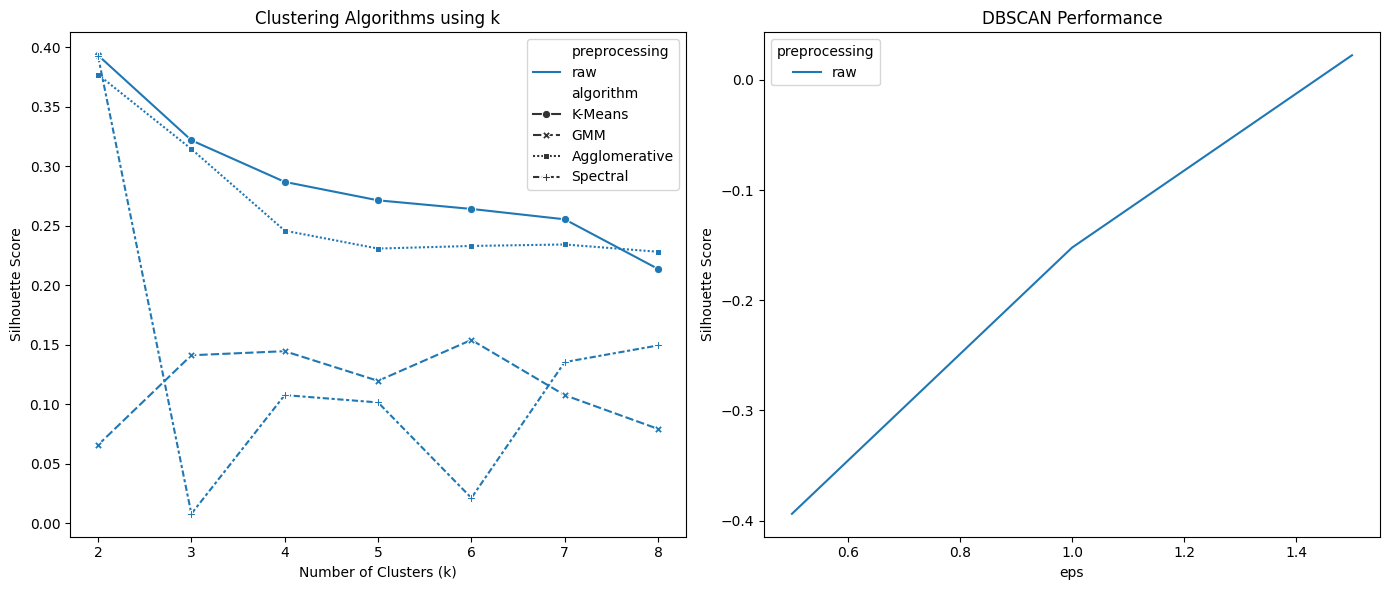

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df_raw = pd.read_csv("updated_data/ames_raw_scores.csv")
df_raw.columns = df_raw.columns.str.strip().str.lower()
# df_raw.columns = df_raw.columns.str.strip()
#df_raw
df_raw_k = df_raw[df_raw["algorithm"] != "DBSCAN"]
df_raw_dbscan = df_raw[df_raw["algorithm"] == "DBSCAN"]

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Plot algorithms using k
sns.lineplot(
    data=df_raw_k,
    x="k",
    y="silhouette",
    hue="preprocessing",
    style="algorithm",
    markers=True,
    ax=axes[0]
)

axes[0].set_title("Clustering Algorithms using k")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Silhouette Score")

# Plot DBSCAN
sns.lineplot(
    data=df_raw_dbscan,
    x="eps",
    y="silhouette",
    hue="preprocessing",
    markers=True,
    #ax=axes[1]
)

axes[1].set_title("DBSCAN Performance")
axes[1].set_xlabel("eps")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

# plt.figure(figsize=(10,6))

# sns.lineplot(
#     data=df_raw,
#     x="k",
#     y="silhouette",
#     hue="preprocessing",
#     style="algorithm",
#     markers=True
# )

# plt.title("Silhouette Score Comparison Across Preprocessing Methods")
# plt.xlabel("Number of Clusters (k)")
# plt.ylabel("Silhouette Score")

# plt.legend(bbox_to_anchor=(1.05,1))
# plt.tight_layout()
# plt.show()

In [15]:
print(df_raw["algorithm"].value_counts())

algorithm
K-Means          7
GMM              7
Agglomerative    7
Spectral         7
DBSCAN           3
Name: count, dtype: int64


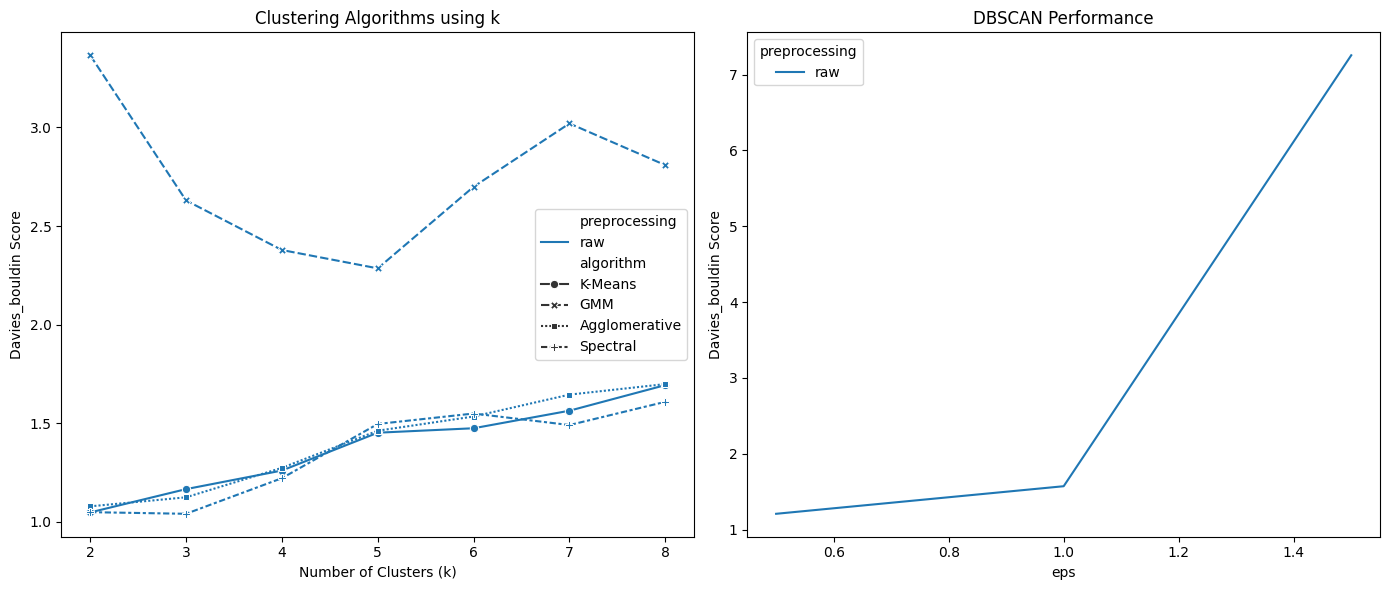

In [3]:
df_raw = pd.read_csv("updated_data/ames_raw_scores.csv")
df_raw.columns = df_raw.columns.str.strip().str.lower()
# df_raw.columns = df_raw.columns.str.strip()
#df_raw
df_raw_k = df_raw[df_raw["algorithm"] != "DBSCAN"]
df_raw_dbscan = df_raw[df_raw["algorithm"] == "DBSCAN"]

fig, axes = plt.subplots(1, 2, figsize=(14,6))
# Plot algorithms using k
sns.lineplot(
    data=df_raw_k,
    x="k",
    y="davies_bouldin",
    hue="preprocessing",
    style="algorithm",
    markers=True,
    ax=axes[0]
)

axes[0].set_title("Clustering Algorithms using k")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Davies_bouldin Score")

# Plot DBSCAN
sns.lineplot(
    data=df_raw_dbscan,
    x="eps",
    y="davies_bouldin",
    hue="preprocessing",
    markers=True,
    #ax=axes[1]
)

axes[1].set_title("DBSCAN Performance")
axes[1].set_xlabel("eps")
axes[1].set_ylabel("Davies_bouldin Score")

plt.tight_layout()
plt.show()

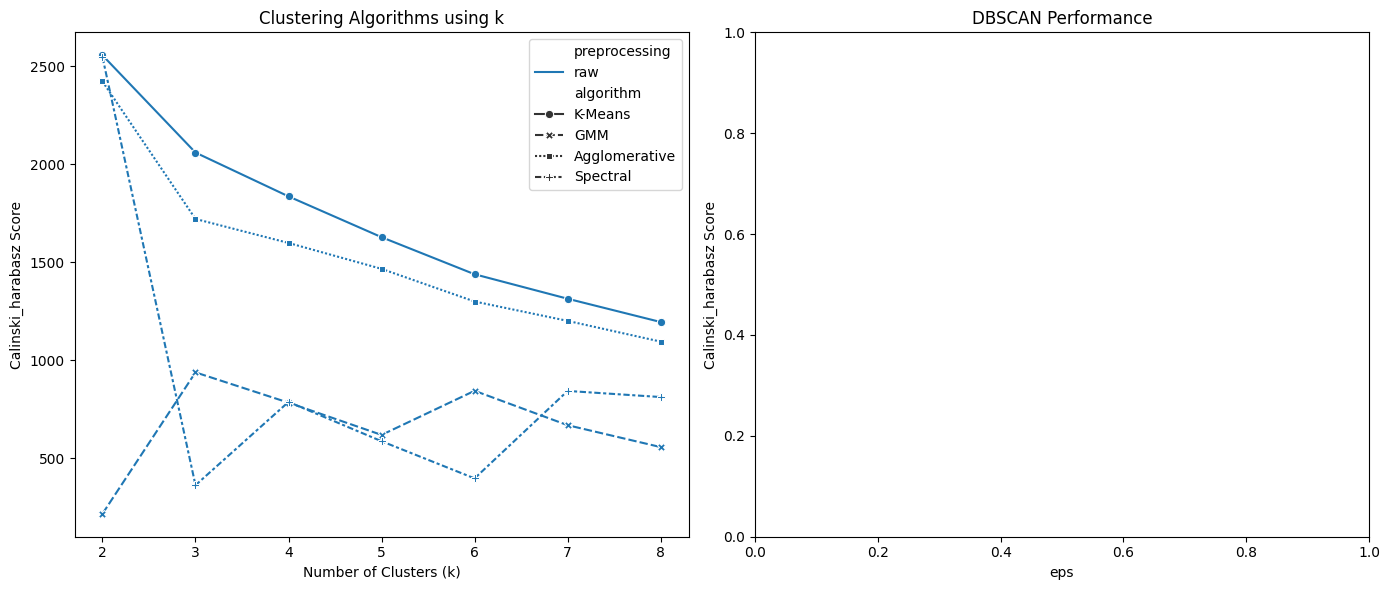

In [18]:
df_raw = pd.read_csv("updated_data/ames_raw_scores.csv")
df_raw.columns = df_raw.columns.str.strip().str.lower()
# df_raw.columns = df_raw.columns.str.strip()
#df_raw
df_raw_k = df_raw[df_raw["algorithm"] != "DBSCAN"]
df_raw_dbscan = df_raw[df_raw["algorithm"] == "DBSCAN"]

fig, axes = plt.subplots(1, 2, figsize=(14,6))
# Plot algorithms using k
sns.lineplot(
    data=df_raw_k,
    x="k",
    y="calinski_harabasz",
    hue="preprocessing",
    style="algorithm",
    markers=True,
    ax=axes[0]
)

axes[0].set_title("Clustering Algorithms using k")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Calinski_harabasz Score")

# Plot DBSCAN
sns.lineplot(
    data=df_raw_dbscan,
    x="eps",
    y="davies_bouldin",
    hue="preprocessing",
    markers=True,
    #ax=axes[1]
)

axes[1].set_title("DBSCAN Performance")
axes[1].set_xlabel("eps")
axes[1].set_ylabel("Calinski_harabasz Score")

plt.tight_layout()
plt.show()

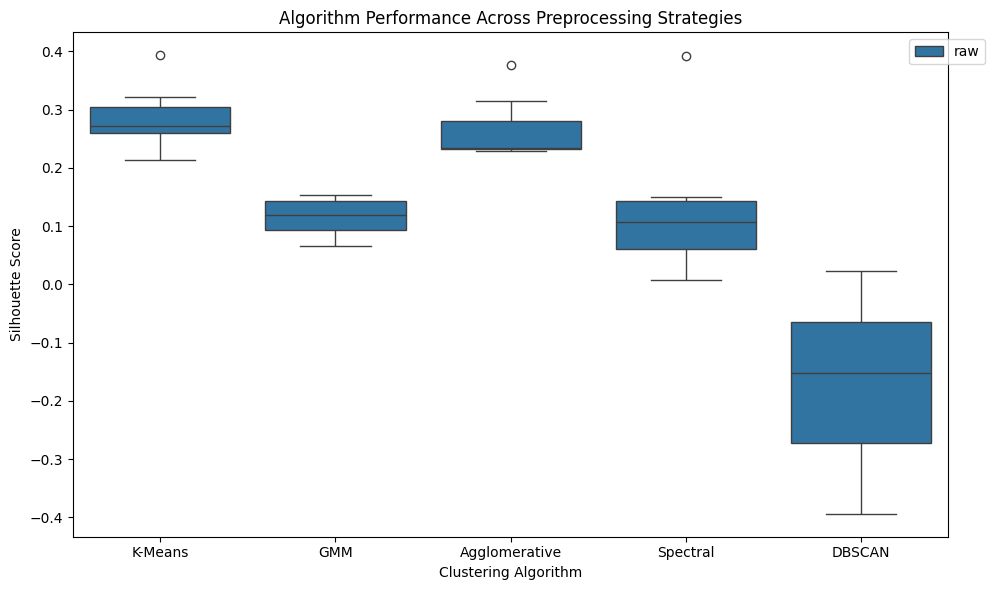

In [4]:

df_raw = pd.read_csv("updated_data/ames_raw_scores.csv")
df_raw.columns = df_raw.columns.str.strip().str.lower()

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_raw,
    x="algorithm",
    y="silhouette",
    hue="preprocessing"
)

plt.title("Algorithm Performance Across Preprocessing Strategies")
plt.xlabel("Clustering Algorithm")
plt.ylabel("Silhouette Score")

plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

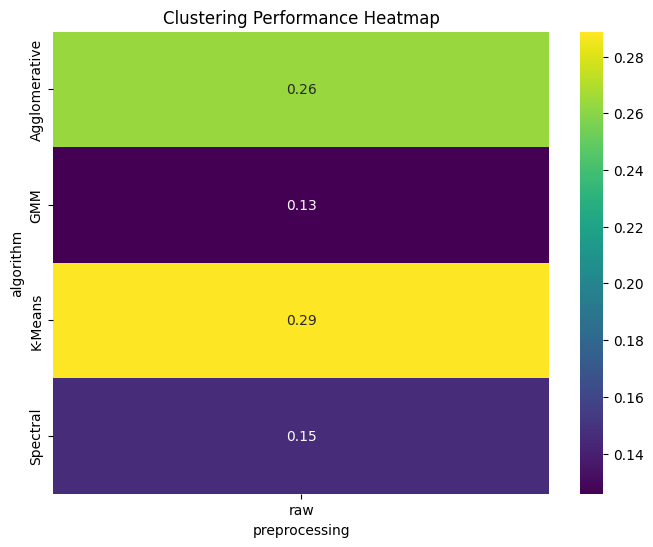

In [ ]:
#Preprocessing Impact Heatmap
pivot = df_raw.pivot_table(
    values="silhouette",
    index="algorithm",
    columns="preprocessing"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="viridis"
)

plt.title("Clustering Performance Heatmap")
plt.show()